## EDA DE DATA


## Import des libries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## exploration des données

In [5]:
df = pd.read_csv("Dataset.csv")
display(df)


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## exploration des donnes

In [ ]:
print("Dimensions :", df.shape)
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## types et stucture

In [ ]:
df.info()
##df.types


## Premier observation

In [ ]:
display(df.head())

###  les missing values and duplicates

### Descriptive statistics

In [ ]:
display(df.describe().round(2))
display(df.describe(include="object"))

###  Analyse technique des variables

In [ ]:
print("Valeurs manquantes par colonne :")
print(df.isna().sum())
print("\nLignes dupliquees :", df.duplicated().sum())

## Classification des variables

## les  Quantitatives(numeriques)

In [ ]:
numeric_col=df.select_dtypes(include='number').columns.tolist()

print(numeric_col)
##Quantitatives : duration, days_left,prix(cible)


['Unnamed: 0', 'duration', 'days_left', 'price']


## Categorials columns

In [ ]:
categorical_cols = ["airline", "source_city", "departure_time", "stops",
                    "arrival_time", "destination_city", "class"]
##continous:airline,source_city,depature_time,stops,arrival_time,destination_city,class


['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


## Analyse univariee

## Variables categorielles

In [9]:
df['airline'].value_counts()


categorical_cols = df.select_dtypes(exclude='number').columns.tolist()
print(categorical_cols)

categorical_cols=['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
for col in categorical_cols:
    print(f"\n {col} ")
    effectifs = df[col].value_counts()
    pourcentages = (df[col].value_counts(normalize=True) * 100).round(2)
    print(pd.DataFrame({"effectif": effectifs, "pourcentage": pourcentages}))


lignes = []
for col in categorical_cols:
    p = df[col].value_counts(normalize=True) * 100
    lignes.append({
        "variable": col,
        "nb_modalites": p.size,
        "dominante": p.idxmax(),
        "part_dominante_%": round(p.max(), 1),
        "plus_rare": p.idxmin(),
        "part_rare_%": round(p.min(), 1),
        "dominante/rare": round(p.max() / p.min(), 1),
        
    })
resume = pd.DataFrame(lignes).set_index("variable")


print(resume)



['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

 airline 
           effectif  pourcentage
airline                         
Vistara      127859        42.60
Air_India     80892        26.95
Indigo        43120        14.37
GO_FIRST      23173         7.72
AirAsia       16098         5.36
SpiceJet       9011         3.00

 source_city 
             effectif  pourcentage
source_city                       
Delhi           61343        20.44
Mumbai          60896        20.29
Bangalore       52061        17.34
Kolkata         46347        15.44
Hyderabad       40806        13.60
Chennai         38700        12.89

 departure_time 
                effectif  pourcentage
departure_time                       
Morning            71146        23.70
Early_Morning      66790        22.25
Evening            65102        21.69
Night              48015        16.00
Afternoon          47794        15.92
Late_Night          1306         0.44

## Visualisation de variables categories

## destination  city

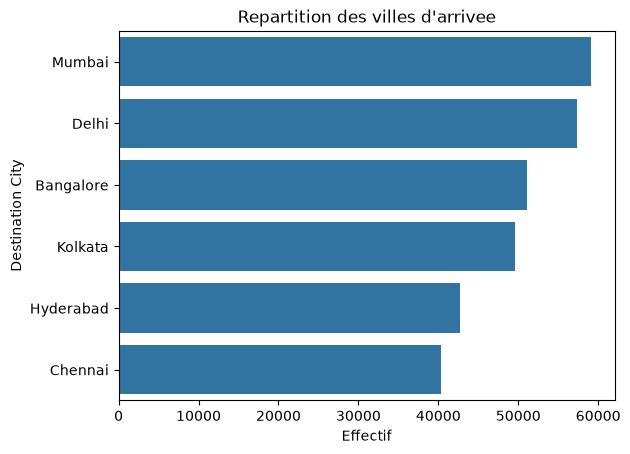

In [10]:

sns.countplot(
    data=df,
    y="destination_city",
    order=df["destination_city"].value_counts().index
)

plt.title("Repartition des villes d'arrivee")
plt.xlabel("Effectif")
plt.ylabel("Destination City")

plt.show()

## Source cITY

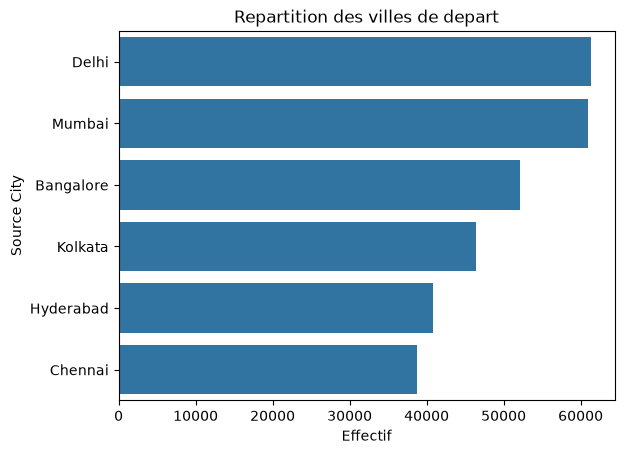

In [11]:

sns.countplot(
    data=df,
    y="source_city",
    order=df["source_city"].value_counts().index
)

plt.title("Repartition des villes de depart")
plt.xlabel("Effectif")
plt.ylabel("Source City")

plt.show()

## Airline

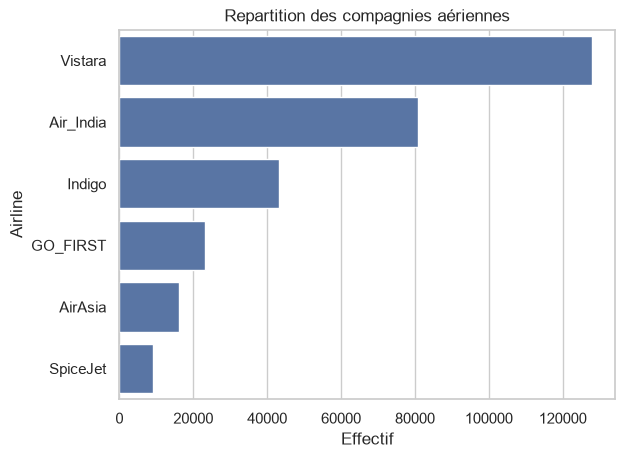

In [12]:


sns.set_theme(style="whitegrid")

sns.countplot(
    data=df,
    y="airline",
    order=df["airline"].value_counts().index
)

plt.title("Repartition des compagnies aériennes")
plt.xlabel("Effectif")
plt.ylabel("Airline")

plt.show()

###  variables quantitatives()


In [15]:
categorial = df[["airline", "flight", "source_city", "destination_city", "class", "stops", "arrival_time", "departure_time"]]
ordinal = df[["class", "stops", "arrival_time", "departure_time"]] 
quantitative = df[[ "duration", "days_left", "price"]] 
cible = [] 

print(categorial.head()) 

print(ordinal.head())


print(quantitative.head()) 
print(categorial.describe())

print(ordinal.describe())

print(quantitative.describe())  



    airline   flight source_city destination_city    class stops  \
0  SpiceJet  SG-8709       Delhi           Mumbai  Economy  zero   
1  SpiceJet  SG-8157       Delhi           Mumbai  Economy  zero   
2   AirAsia   I5-764       Delhi           Mumbai  Economy  zero   
3   Vistara   UK-995       Delhi           Mumbai  Economy  zero   
4   Vistara   UK-963       Delhi           Mumbai  Economy  zero   

    arrival_time departure_time  
0          Night        Evening  
1        Morning  Early_Morning  
2  Early_Morning  Early_Morning  
3      Afternoon        Morning  
4        Morning        Morning  
     class stops   arrival_time departure_time
0  Economy  zero          Night        Evening
1  Economy  zero        Morning  Early_Morning
2  Economy  zero  Early_Morning  Early_Morning
3  Economy  zero      Afternoon        Morning
4  Economy  zero        Morning        Morning
   duration  days_left  price
0      2.17          1   5953
1      2.33          1   5953
2      2.17    